In [1]:
# 1. Update Torch and Torchvision to ensure compatibility
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q

# 2. Update Transformers and Accelerate (critical for Qwen2.5 support)
!pip install --upgrade transformers accelerate bitsandbytes -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 153.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 49.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.2.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [3]:
!nvidia-smi

Tue Feb 17 08:10:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   29C    P0             72W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

GPU Available: NVIDIA H100 80GB HBM3
GPU Memory: 85.0 GB

STEERING VECTOR PD — CONFERENCE EXPERIMENT
Model: Qwen/Qwen2.5-32B-Instruct
Device: cuda
GPU: NVIDIA H100 80GB HBM3
Calibration rounds: 30
Eval rounds: 50
Reps/condition: 5
Opponents: ['TFT', 'AllC', 'AllD', 'WSLS', 'Random']
Alpha sweep (14): [-2.0, -1.0, -0.5, -0.2, -0.1, 0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
Extraction layers: [-1, -16, -32, -48]
Estimated total games: ~1475

Initializing Steering LLM Player
Model: Qwen/Qwen2.5-32B-Instruct
Device: cuda
Quantization: True

Loading tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

✓ Model loaded | Transformer layers: 64
  VRAM allocated: 19.25 GB


PHASE 1: CALIBRATION


  Cal AllC:   0%|          | 0/30 [00:00<?, ?it/s]

    → 30 vecs | Coop: 100% | Dim: 5120


  Cal AllD:   0%|          | 0/30 [00:00<?, ?it/s]

    → 30 vecs | Coop: 0% | Dim: 5120
  Layer -1: norm = 51.9747
  Layer -16: norm = 95.4071
  Layer -32: norm = 16.1495
  Layer -48: norm = 3.5434
✓ Steering vectors saved
  Random vector norm: 51.9747 (matches primary SV norm)

PHASE 2: BASELINE (no steering, no instruction)
    [Baseline] vs TFT: DDDDDDDDDDDDDDDDDDDDDDDDDDDDDD… | Coop 0% | Pay 1.08
    [Baseline] vs AllC: DDDDDDDDDDDDDDDDDDDDCCCCCCCCCC… | Coop 60% | Pay 3.80
    [Baseline] vs AllD: DDDDDDDDDDDDDDDDDDDDDDDDDDDDDD… | Coop 0% | Pay 1.00
    [Baseline] vs WSLS: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC… | Coop 100% | Pay 3.00
    [Baseline] vs Random: DDDDDDDDDDDDDDDDDDDDDDDDDDDDDD… | Coop 2% | Pay 3.22

PHASE 3: PROMPT-INSTRUCTED ('please cooperate')
    [PromptCooperate] vs TFT: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC… | Coop 100% | Pay 3.00
    [PromptCooperate] vs AllC: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC… | Coop 100% | Pay 3.00
    [PromptCooperate] vs AllD: CCCCDDDDDCDDDDDDCCDDDDDDDDCDDD… | Coop 28% | Pay 0.72
    [PromptCooperate] vs WSLS

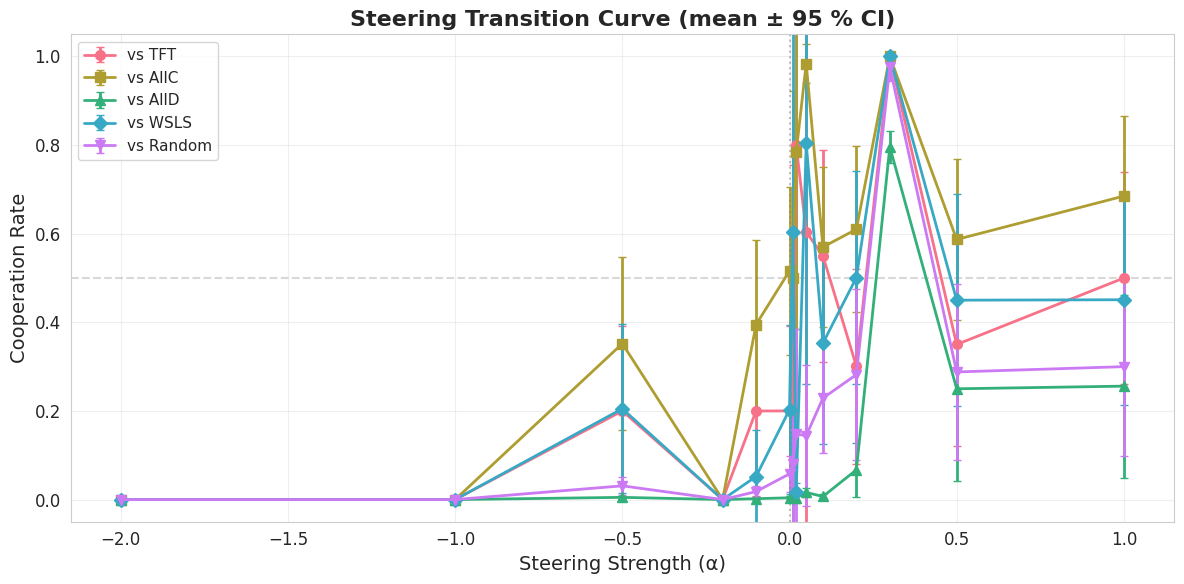

✓ transition_curve.png saved


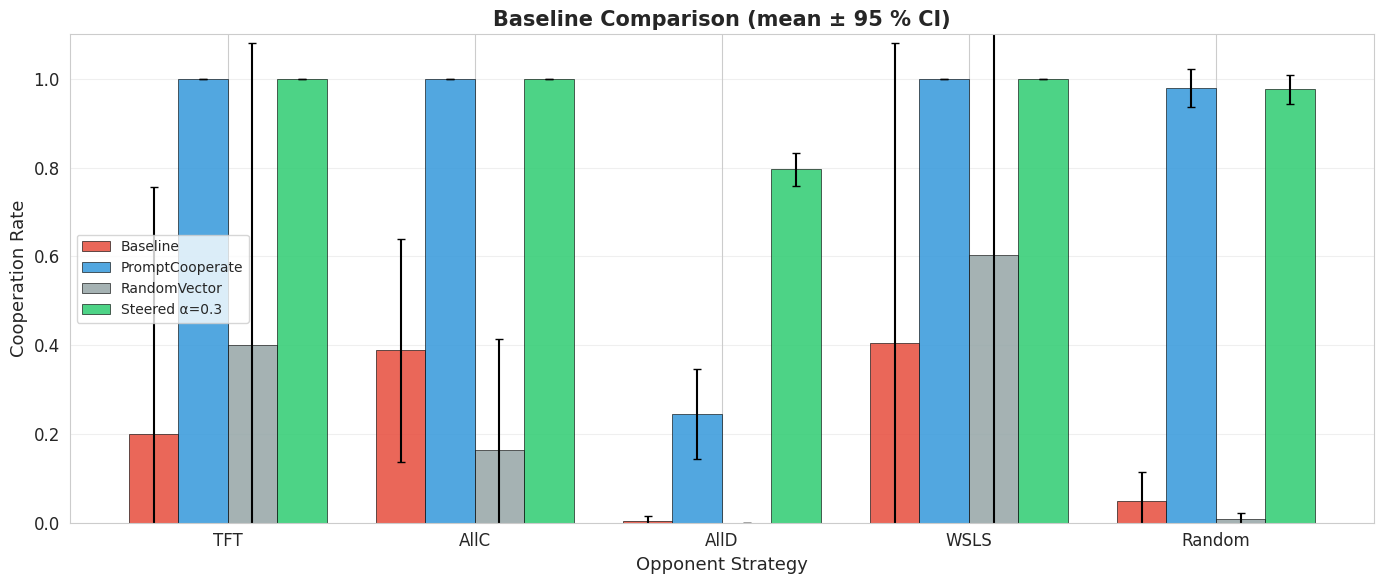

✓ baseline_comparison.png saved


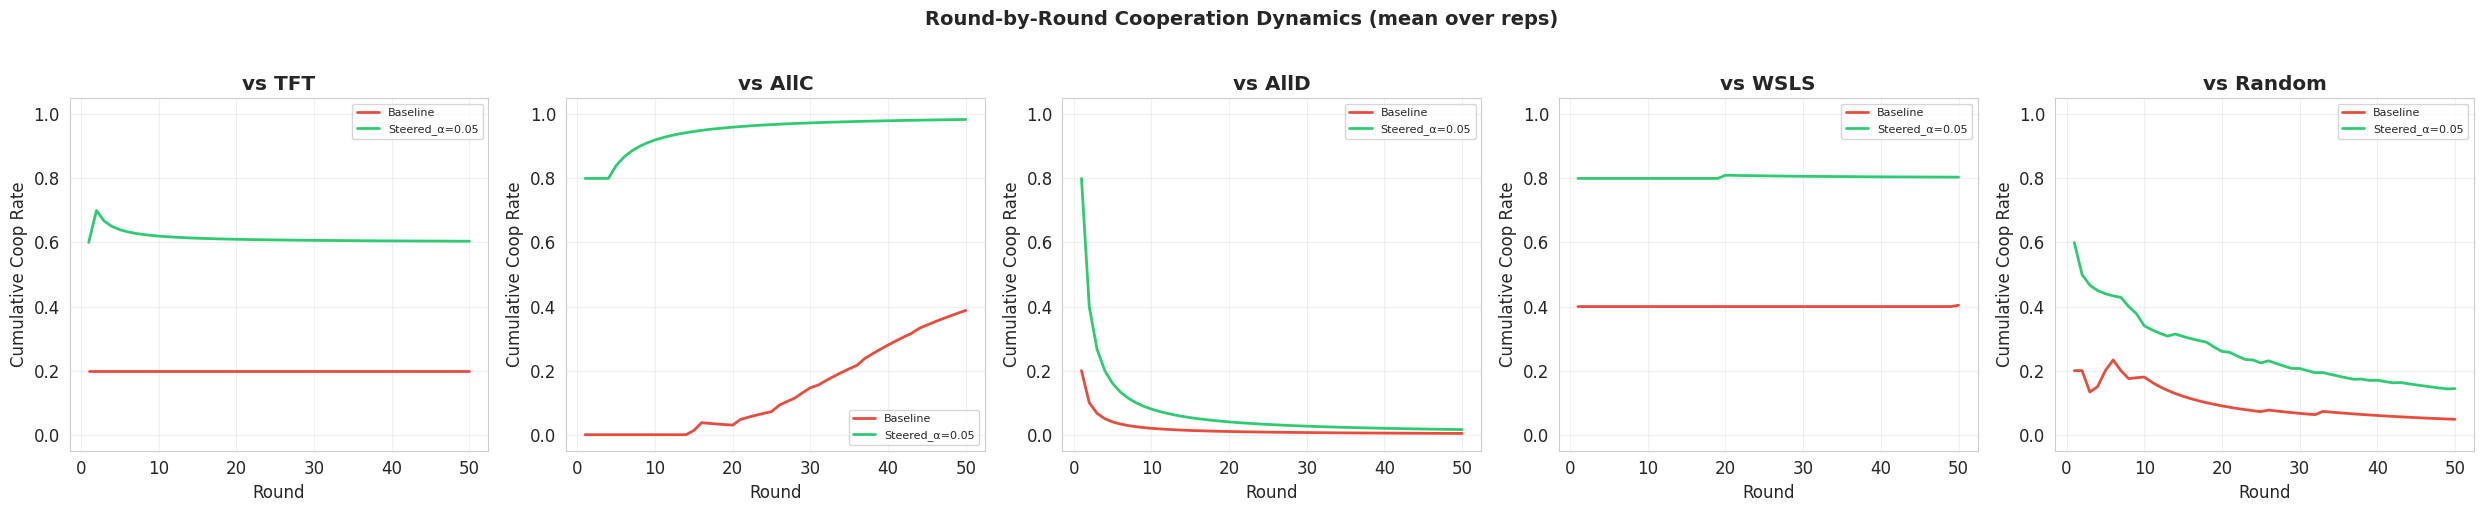

✓ round_dynamics.png saved


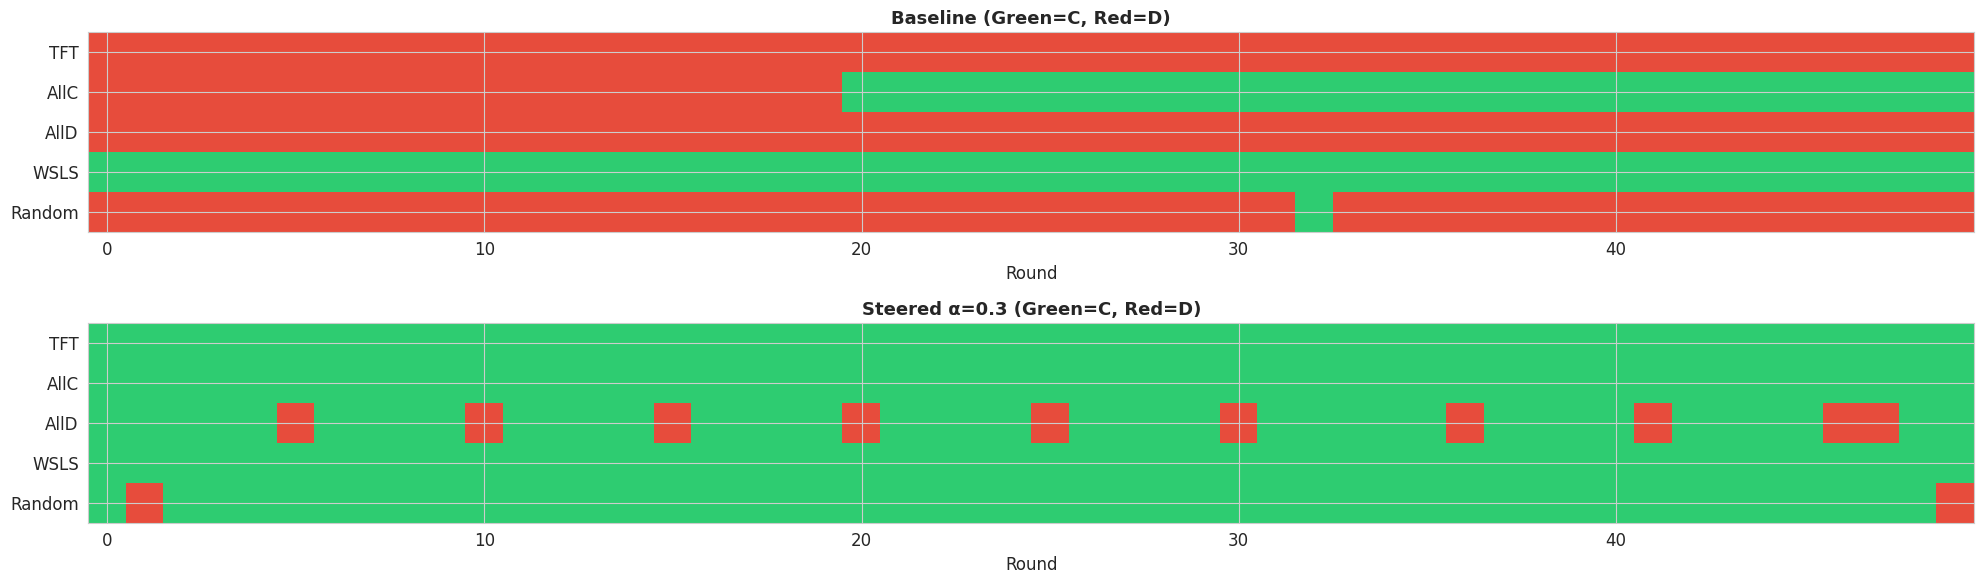

✓ action_heatmap.png saved

SAVING RESULTS

EXPERIMENT COMPLETE!
Total games played: 950
Results saved to: /kaggle/working/steering_outputs
  - all_games_raw.csv          (per-game raw data)
  - aggregate_stats.csv        (mean/std/CI per condition)
  - significance_tests.csv     (Wilcoxon p-values, Cohen's d)
  - experiment_summary.json    (config + metadata)
  - transition_curve.png       (main result)
  - baseline_comparison.png    (3 baselines + best steered)
  - round_dynamics.png         (per-round trajectories)
  - action_heatmap.png         (C/D grid)
  - steering_vector_layer*.npy (saved vectors)

✓ All tasks completed successfully!

Final GPU memory: 16.17 GB


In [4]:
"""
Steering Vector Prisoner's Dilemma Experiment — Conference Quality
==================================================================

Uses steering vector (AllC − AllD) to steer LLM cooperation in the
Iterated Prisoner's Dilemma.  Compares baseline, prompt-instructed,
random-vector, and steered conditions with fine-grained alpha sweep
(including negative) and multiple repetitions for statistical rigour.

Pipeline:
  Phase 1: Calibration — collect hidden states for AllC / AllD
  Phase 2: Compute steering vector(s) at multiple layers
  Phase 3: Baseline & prompt-instructed games
  Phase 4: Random-vector control games
  Phase 5: Steered games (alpha sweep, multi-layer)
  Phase 6: Statistical analysis & visualization

Designed for Kaggle H100 80GB GPU with 4-bit quantization.
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from tqdm.auto import tqdm

# Statistics
from scipy import stats as scipy_stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12


class NumpyEncoder(json.JSONEncoder):
    """Custom JSON encoder for numpy types"""
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
            return int(obj)
        if isinstance(obj, (np.float64, np.float32, np.float16)):
            return float(obj)
        return super().default(obj)


# ============================================================================
# CONFIGURATION
# ============================================================================

class SteeringConfig:
    """Configuration for the steering vector experiment"""

    # Model settings
    MODEL_NAME = "Qwen/Qwen2.5-32B-Instruct"
    USE_QUANTIZATION = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TEMPERATURE = 0.7

    # ── Steering vector settings ──
    # Fine-grained sweep including negative (bidirectionality test)
    ALPHA_SWEEP = [
        -2.0, -1.0, -0.5, -0.2, -0.1,
        0.0,
        0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0,
    ]

    # Layers to extract steering vectors from (ablation)
    EXTRACTION_LAYERS = [-1, -16, -32, -48]
    # Primary layer used in main sweep (index into hidden_states)
    PRIMARY_LAYER = -1

    # ── Calibration settings ──
    CALIBRATION_ROUNDS = 30
    CALIBRATION_OPPONENT = 'TFT'

    # ── Evaluation settings ──
    EVAL_ROUNDS = 50
    EVAL_GAMES_PER_OPPONENT = 5  # repetitions for statistics
    EVAL_OPPONENT_STRATEGIES = ['TFT', 'AllC', 'AllD', 'WSLS', 'Random']

    # ── Strategy prompts ──
    STRATEGY_PROMPTS = {
        'AllC': ("Your strategy is 'Always Cooperate': You must choose "
                 "C (Cooperate) in every single round, regardless of "
                 "what the opponent does."),
        'AllD': ("Your strategy is 'Always Defect': You must choose "
                 "D (Defect) in every single round, regardless of "
                 "what the opponent does."),
    }
    COOPERATE_INSTRUCTION = (
        "\nPlease try to cooperate with your opponent as much as possible.\n"
    )

    # ── Output ──
    SAVE_PLOTS = True
    OUTPUT_DIR = "/kaggle/working/steering_outputs"

    # ── Memory ──
    CLEAR_CACHE_FREQUENCY = 10


os.makedirs(SteeringConfig.OUTPUT_DIR, exist_ok=True)


# ============================================================================
# OPPONENT STRATEGIES
# ============================================================================

def get_opponent_action(strategy: str, history: List[Tuple[str, str]],
                        my_last_action: str) -> str:
    if strategy == 'AllC':
        return 'C'
    elif strategy == 'AllD':
        return 'D'
    elif strategy == 'TFT':
        return 'C' if len(history) == 0 else history[-1][0]
    elif strategy == 'WSLS':
        if len(history) == 0:
            return 'C'
        my_prev, opp_prev = history[-1]
        if opp_prev == 'C' and my_prev == 'C':
            opp_payoff = 3
        elif opp_prev == 'D' and my_prev == 'D':
            opp_payoff = 1
        elif opp_prev == 'D' and my_prev == 'C':
            opp_payoff = 5
        else:
            opp_payoff = 0
        if opp_payoff >= 3:
            return opp_prev
        return 'D' if opp_prev == 'C' else 'C'
    elif strategy == 'Grudger':
        if any(m == 'D' for m, _ in history):
            return 'D'
        return 'C'
    elif strategy == 'Random':
        return np.random.choice(['C', 'D'])
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


def calculate_payoff(my_action: str, opponent_action: str) -> float:
    if my_action == 'C' and opponent_action == 'C':
        return 3.0
    elif my_action == 'D' and opponent_action == 'D':
        return 1.0
    elif my_action == 'D' and opponent_action == 'C':
        return 5.0
    else:
        return 0.0


# ============================================================================
# STEERING LLM PLAYER
# ============================================================================

class SteeringLLMPlayer:
    """LLM player with steering vector injection capability."""

    def __init__(self, model_name: str = None, use_quantization: bool = True):
        if model_name is None:
            model_name = SteeringConfig.MODEL_NAME

        print(f"{'='*60}")
        print(f"Initializing Steering LLM Player")
        print(f"Model: {model_name}")
        print(f"Device: {SteeringConfig.DEVICE}")
        print(f"Quantization: {use_quantization}")
        print(f"{'='*60}\n")

        self.model_name = model_name
        self.device = SteeringConfig.DEVICE

        # Tokenizer
        print("Loading tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # Model
        if use_quantization and self.device == "cuda":
            print("Setting up 4-bit quantization...")
            qcfg = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4",
            )
            print("Loading model with quantization...")
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name, quantization_config=qcfg, device_map="auto",
                trust_remote_code=True, output_hidden_states=True)
        else:
            dtype = torch.float16 if self.device == "cuda" else torch.float32
            print("Loading model...")
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name, torch_dtype=dtype, device_map="auto",
                trust_remote_code=True, output_hidden_states=True)

        self.model.eval()
        self.n_layers = len(self.model.model.layers) if hasattr(self.model, 'model') and hasattr(self.model.model, 'layers') else 0

        print(f"✓ Model loaded | Transformer layers: {self.n_layers}")
        if torch.cuda.is_available():
            print(f"  VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB\n")

    # ── Prompt creation ───────────────────────────────────────────────

    def create_game_prompt(self, history: List[Tuple[str, str]],
                           strategy_instruction: str = "",
                           opponent_last_move: Optional[str] = None) -> str:
        prompt = (
            "You are playing the Iterated Prisoner's Dilemma game. "
            "In each round:\n"
            "- Choose C (Cooperate) or D (Defect)\n"
            "- Payoffs: Both C = 3pts, Both D = 1pt, "
            "C vs D = 0pts for C and 5pts for D\n"
            f"{strategy_instruction}\n"
        )
        if history:
            prompt += "Game History (last 5 rounds):\n"
            window = history[-5:]
            start = len(history) - len(window) + 1
            for i, (my, opp) in enumerate(window):
                prompt += f"Round {start+i}: You={my}, Opponent={opp}\n"
        if opponent_last_move:
            prompt += f"\nOpponent's last move: {opponent_last_move}\n"
        prompt += "\nYour move (respond with only C or D): "
        return prompt

    # ── Action extraction ─────────────────────────────────────────────

    def _extract_action_from_logits(self, logits: torch.Tensor) -> str:
        c_id = self.tokenizer.encode('C', add_special_tokens=False)[0]
        d_id = self.tokenizer.encode('D', add_special_tokens=False)[0]
        c_logit = logits[c_id].item()
        d_logit = logits[d_id].item()
        if SteeringConfig.TEMPERATURE <= 0:
            return 'C' if c_logit > d_logit else 'D'
        rl = torch.tensor([c_logit, d_logit], device=self.device)
        probs = torch.softmax(rl / SteeringConfig.TEMPERATURE, dim=0)
        return 'C' if torch.multinomial(probs, 1).item() == 0 else 'D'

    # ── Calibration: collect hidden-state vectors ─────────────────────

    def collect_strategy_vectors(
        self, strategy: str, opponent_strategy: str,
        n_rounds: int, layer_indices: List[int]
    ) -> Dict[int, List[np.ndarray]]:
        """Play n_rounds and collect hidden-state vectors at multiple layers.

        Returns {layer_index: [vec_round0, vec_round1, ...]}.
        """
        instruction = SteeringConfig.STRATEGY_PROMPTS.get(strategy, "")
        if instruction:
            instruction = f"\n{instruction}\n"

        history: List[Tuple[str, str]] = []
        vectors: Dict[int, List[np.ndarray]] = {li: [] for li in layer_indices}
        opp_last = None

        print(f"  Collecting {n_rounds} vectors for '{strategy}' "
              f"vs '{opponent_strategy}' at layers {layer_indices}...")

        for rnd in tqdm(range(n_rounds), desc=f"  Cal {strategy}", leave=False):
            prompt = self.create_game_prompt(history, instruction, opp_last)
            inputs = self.tokenizer(
                prompt, return_tensors="pt", padding=True,
                truncation=True, max_length=1024)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs, output_hidden_states=True)
                for li in layer_indices:
                    vec = outputs.hidden_states[li][0, -1, :].cpu().float().numpy()
                    vectors[li].append(vec)
                action = self._extract_action_from_logits(outputs.logits[0, -1, :])

            opp_action = get_opponent_action(opponent_strategy, history, action)
            history.append((action, opp_action))
            opp_last = opp_action

            if (rnd + 1) % SteeringConfig.CLEAR_CACHE_FREQUENCY == 0:
                torch.cuda.empty_cache()

        coop = sum(1 for a, _ in history if a == 'C') / len(history)
        dim = vectors[layer_indices[0]][0].shape[0]
        print(f"    → {n_rounds} vecs | Coop: {coop:.0%} | Dim: {dim}")
        return vectors

    # ── Compute steering vector ───────────────────────────────────────

    @staticmethod
    def compute_steering_vector(
        allc_vecs: List[np.ndarray], alld_vecs: List[np.ndarray]
    ) -> np.ndarray:
        mean_c = np.mean(allc_vecs, axis=0)
        mean_d = np.mean(alld_vecs, axis=0)
        sv = mean_c - mean_d
        return sv

    # ── Action with/without steering ──────────────────────────────────

    def get_action_with_steering(
        self, prompt: str, steering_vector: np.ndarray, alpha: float
    ) -> str:
        """Add α·steering_vector to final hidden states, recompute logits."""
        sv_tensor = torch.tensor(
            steering_vector, dtype=torch.float16, device=self.device)

        inputs = self.tokenizer(
            prompt, return_tensors="pt", padding=True,
            truncation=True, max_length=1024)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs, output_hidden_states=True)
            final_h = outputs.hidden_states[-1].clone()
            final_h[:, -1, :] += alpha * sv_tensor.to(final_h.dtype)
            steered_logits = self.model.lm_head(final_h)
            action = self._extract_action_from_logits(steered_logits[0, -1, :])
        return action

    def get_action_baseline(self, prompt: str) -> str:
        inputs = self.tokenizer(
            prompt, return_tensors="pt", padding=True,
            truncation=True, max_length=1024)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = self.model(**inputs)
            action = self._extract_action_from_logits(outputs.logits[0, -1, :])
        return action

    # ── Play a full game ──────────────────────────────────────────────

    def play_game(
        self, opponent_strategy: str, n_rounds: int,
        steering_vector: Optional[np.ndarray] = None,
        alpha: float = 0.0,
        prompt_instruction: str = "",
        condition_label: str = "",
        verbose: bool = False,
    ) -> Dict:
        history: List[Tuple[str, str]] = []
        round_actions: List[str] = []
        round_payoffs: List[float] = []
        opp_last = None

        for rnd in range(n_rounds):
            prompt = self.create_game_prompt(history, prompt_instruction, opp_last)

            if steering_vector is not None and alpha != 0.0:
                action = self.get_action_with_steering(prompt, steering_vector, alpha)
            else:
                action = self.get_action_baseline(prompt)

            opp_action = get_opponent_action(opponent_strategy, history, action)
            payoff = calculate_payoff(action, opp_action)

            round_actions.append(action)
            round_payoffs.append(payoff)
            history.append((action, opp_action))
            opp_last = opp_action

            if (rnd + 1) % SteeringConfig.CLEAR_CACHE_FREQUENCY == 0:
                torch.cuda.empty_cache()

        action_seq = ''.join(round_actions)
        coop_rate = sum(1 for a in round_actions if a == 'C') / n_rounds
        avg_payoff = float(np.mean(round_payoffs))

        if verbose:
            print(f"    [{condition_label}] vs {opponent_strategy}: "
                  f"{action_seq[:30]}{'…' if n_rounds>30 else ''} "
                  f"| Coop {coop_rate:.0%} | Pay {avg_payoff:.2f}")

        return {
            'condition': condition_label,
            'opponent': opponent_strategy,
            'alpha': alpha,
            'n_rounds': n_rounds,
            'coop_rate': coop_rate,
            'avg_payoff': avg_payoff,
            'total_payoff': float(sum(round_payoffs)),
            'action_sequence': action_seq,
            'round_actions': round_actions,
            'round_payoffs': round_payoffs,
        }


# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def compute_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-condition statistics with CI and effect size."""
    rows = []
    for (cond, alpha, opp), grp in df.groupby(
            ['condition', 'alpha', 'opponent']):
        cr = grp['coop_rate'].values
        pay = grp['avg_payoff'].values
        n = len(cr)
        cr_mean, cr_std = cr.mean(), cr.std(ddof=1) if n > 1 else 0.0
        pay_mean, pay_std = pay.mean(), pay.std(ddof=1) if n > 1 else 0.0

        # 95 % CI (t-distribution)
        if n > 1:
            t_crit = scipy_stats.t.ppf(0.975, df=n - 1)
            cr_ci = t_crit * cr_std / np.sqrt(n)
            pay_ci = t_crit * pay_std / np.sqrt(n)
        else:
            cr_ci = pay_ci = 0.0

        rows.append({
            'condition': cond, 'alpha': alpha, 'opponent': opp,
            'n': n,
            'coop_mean': cr_mean, 'coop_std': cr_std, 'coop_ci95': cr_ci,
            'payoff_mean': pay_mean, 'payoff_std': pay_std, 'payoff_ci95': pay_ci,
        })
    return pd.DataFrame(rows)


def significance_tests(df_raw: pd.DataFrame, baseline_cond: str = 'Baseline'):
    """Wilcoxon signed-rank tests: each condition vs baseline."""
    results = []
    baseline = df_raw[df_raw['condition'] == baseline_cond]
    other_conditions = df_raw[df_raw['condition'] != baseline_cond]

    for (cond, alpha, opp), grp in other_conditions.groupby(
            ['condition', 'alpha', 'opponent']):
        bl = baseline[(baseline['opponent'] == opp)]['coop_rate'].values
        st = grp['coop_rate'].values
        n = min(len(bl), len(st))
        if n < 3:
            p_val = np.nan
            effect = np.nan
        else:
            bl_s, st_s = bl[:n], st[:n]
            diff = st_s - bl_s
            if np.all(diff == 0):
                p_val = 1.0
                effect = 0.0
            else:
                try:
                    stat, p_val = scipy_stats.wilcoxon(bl_s, st_s)
                except ValueError:
                    p_val = np.nan
                pooled_std = np.sqrt((bl_s.var() + st_s.var()) / 2)
                effect = (st_s.mean() - bl_s.mean()) / pooled_std if pooled_std > 0 else 0.0

        results.append({
            'condition': cond, 'alpha': alpha, 'opponent': opp,
            'p_value': p_val, 'cohens_d': effect,
            'baseline_mean': bl.mean() if len(bl) > 0 else np.nan,
            'condition_mean': st.mean() if len(st) > 0 else np.nan,
            'delta': st.mean() - bl.mean() if len(bl) > 0 and len(st) > 0 else np.nan,
        })
    return pd.DataFrame(results)


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_transition_curve(df_agg: pd.DataFrame, output_dir: str):
    """Main result: cooperation rate vs alpha with error bars."""
    steered = df_agg[df_agg['condition'] == 'Steered'].copy()
    if steered.empty:
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    opponents = SteeringConfig.EVAL_OPPONENT_STRATEGIES
    markers = ['o', 's', '^', 'D', 'v']
    colors = sns.color_palette('husl', len(opponents))

    for i, opp in enumerate(opponents):
        sub = steered[steered['opponent'] == opp].sort_values('alpha')
        ax.errorbar(sub['alpha'], sub['coop_mean'], yerr=sub['coop_ci95'],
                    fmt=f'-{markers[i]}', color=colors[i], linewidth=2,
                    markersize=7, capsize=3, label=f'vs {opp}')

    ax.axvline(0, color='gray', ls=':', alpha=.5)
    ax.axhline(0.5, color='gray', ls='--', alpha=.3)
    ax.set_xlabel('Steering Strength (α)', fontsize=14)
    ax.set_ylabel('Cooperation Rate', fontsize=14)
    ax.set_title('Steering Transition Curve (mean ± 95 % CI)',
                 fontsize=16, fontweight='bold')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(fontsize=11, loc='best')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/transition_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ transition_curve.png saved")


def plot_baseline_comparison(df_agg: pd.DataFrame, output_dir: str):
    """Bar chart comparing all baselines vs best alpha."""
    conditions = ['Baseline', 'PromptCooperate', 'RandomVector']
    # Find best steered alpha (highest mean coop across opponents)
    steered = df_agg[df_agg['condition'] == 'Steered']
    if not steered.empty:
        best_alpha = (steered.groupby('alpha')['coop_mean']
                      .mean().idxmax())
        best_steered = steered[steered['alpha'] == best_alpha].copy()
        best_steered['condition'] = f'Steered α={best_alpha}'
        conditions.append(f'Steered α={best_alpha}')
    else:
        best_steered = pd.DataFrame()

    plot_df = pd.concat([
        df_agg[df_agg['condition'].isin(['Baseline', 'PromptCooperate', 'RandomVector'])],
        best_steered
    ])

    if plot_df.empty:
        return

    opponents = SteeringConfig.EVAL_OPPONENT_STRATEGIES
    n_conds = len(conditions)
    x = np.arange(len(opponents))
    width = 0.8 / n_conds
    colors_bar = ['#e74c3c', '#3498db', '#95a5a6', '#2ecc71']

    fig, ax = plt.subplots(figsize=(14, 6))
    for ci, cond in enumerate(conditions):
        sub = plot_df[plot_df['condition'] == cond]
        vals = [sub[sub['opponent'] == o]['coop_mean'].values[0]
                if len(sub[sub['opponent'] == o]) > 0 else 0 for o in opponents]
        errs = [sub[sub['opponent'] == o]['coop_ci95'].values[0]
                if len(sub[sub['opponent'] == o]) > 0 else 0 for o in opponents]
        ax.bar(x + ci * width - (n_conds - 1) * width / 2, vals, width,
               yerr=errs, capsize=3, label=cond, color=colors_bar[ci],
               alpha=0.85, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Opponent Strategy', fontsize=13)
    ax.set_ylabel('Cooperation Rate', fontsize=13)
    ax.set_title('Baseline Comparison (mean ± 95 % CI)',
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(opponents)
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/baseline_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ baseline_comparison.png saved")


def plot_layer_ablation(layer_results: Dict[int, pd.DataFrame], output_dir: str):
    """Heatmap: layer × alpha → mean cooperation rate (averaged over opponents)."""
    layers = sorted(layer_results.keys())
    if not layers:
        return

    # Get alpha values from the first layer's steered results
    sample_df = layer_results[layers[0]]
    steered = sample_df[sample_df['condition'] == 'Steered']
    if steered.empty:
        return
    alphas = sorted(steered['alpha'].unique())

    heat = np.zeros((len(layers), len(alphas)))
    for li, layer in enumerate(layers):
        st = layer_results[layer]
        st = st[st['condition'] == 'Steered']
        for ai, alpha in enumerate(alphas):
            sub = st[st['alpha'] == alpha]
            heat[li, ai] = sub['coop_mean'].mean() if len(sub) > 0 else np.nan

    fig, ax = plt.subplots(figsize=(max(12, len(alphas) * 0.8), 4))
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=[f'{a}' for a in alphas],
                yticklabels=[f'Layer {l}' for l in layers],
                ax=ax, vmin=0, vmax=1, cbar_kws={'label': 'Coop Rate'})
    ax.set_xlabel('Steering Alpha (α)', fontsize=13)
    ax.set_ylabel('Extraction Layer', fontsize=13)
    ax.set_title('Layer × Alpha Ablation (mean coop rate)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/layer_ablation.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ layer_ablation.png saved")


def plot_round_dynamics(df_raw: pd.DataFrame, output_dir: str):
    """Per-round cooperation trajectory (averaged across reps)."""
    opponents = SteeringConfig.EVAL_OPPONENT_STRATEGIES
    conditions_to_plot = ['Baseline']
    # Pick a moderate alpha for steered
    steered = df_raw[df_raw['condition'] == 'Steered']
    if not steered.empty:
        steered_positive = steered[steered['alpha'] > 0]
        if not steered_positive.empty:
            # Pick smallest alpha that gives >50% avg coop across opponents
            for alpha in sorted(steered_positive['alpha'].unique()):
                sub = steered_positive[steered_positive['alpha'] == alpha]
                if sub['coop_rate'].mean() > 0.4:
                    conditions_to_plot.append(f'Steered_α={alpha}')
                    break
            else:
                # Just pick smallest positive alpha
                alpha = sorted(steered_positive['alpha'].unique())[0]
                conditions_to_plot.append(f'Steered_α={alpha}')

    fig, axes = plt.subplots(1, len(opponents),
                             figsize=(5 * len(opponents), 5))
    if len(opponents) == 1:
        axes = [axes]

    colors_line = {'Baseline': '#e74c3c'}
    for c in conditions_to_plot:
        if c.startswith('Steered'):
            colors_line[c] = '#2ecc71'

    for oi, opp in enumerate(opponents):
        for cond_label in conditions_to_plot:
            if cond_label == 'Baseline':
                sub = df_raw[(df_raw['condition'] == 'Baseline') &
                             (df_raw['opponent'] == opp)]
            else:
                alpha_val = float(cond_label.split('=')[1])
                sub = df_raw[(df_raw['condition'] == 'Steered') &
                             (df_raw['alpha'] == alpha_val) &
                             (df_raw['opponent'] == opp)]

            if sub.empty:
                continue

            # Compute per-round coop rate averaged across reps
            action_lists = sub['round_actions'].tolist()
            n_rounds = len(action_lists[0]) if action_lists else 0
            if n_rounds == 0:
                continue
            coop_per_round = np.zeros(n_rounds)
            for al in action_lists:
                for r in range(min(len(al), n_rounds)):
                    coop_per_round[r] += (1 if al[r] == 'C' else 0)
            coop_per_round /= len(action_lists)

            cum_coop = np.cumsum(coop_per_round) / np.arange(1, n_rounds + 1)
            axes[oi].plot(range(1, n_rounds + 1), cum_coop,
                         linewidth=2, label=cond_label,
                         color=colors_line.get(cond_label, '#3498db'))

        axes[oi].set_xlabel('Round')
        axes[oi].set_ylabel('Cumulative Coop Rate')
        axes[oi].set_title(f'vs {opp}', fontweight='bold')
        axes[oi].set_ylim([-0.05, 1.05])
        axes[oi].legend(fontsize=8)
        axes[oi].grid(alpha=0.3)

    plt.suptitle('Round-by-Round Cooperation Dynamics (mean over reps)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/round_dynamics.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ round_dynamics.png saved")


def plot_action_heatmap(df_raw: pd.DataFrame, output_dir: str):
    """Action heatmap for baseline vs best steered (first rep)."""
    opponents = SteeringConfig.EVAL_OPPONENT_STRATEGIES

    steered = df_raw[df_raw['condition'] == 'Steered']
    if steered.empty:
        return
    steered_pos = steered[steered['alpha'] > 0]
    if steered_pos.empty:
        return
    best_alpha = steered_pos.groupby('alpha')['coop_rate'].mean().idxmax()

    fig, axes = plt.subplots(2, 1,
                             figsize=(max(14, SteeringConfig.EVAL_ROUNDS * 0.4), 6))

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#e74c3c', '#2ecc71'])

    for ax_idx, (cond_name, cond_filter, alpha_filter) in enumerate([
        ('Baseline', 'Baseline', None),
        (f'Steered α={best_alpha}', 'Steered', best_alpha),
    ]):
        matrix = np.zeros((len(opponents), SteeringConfig.EVAL_ROUNDS))
        for i, opp in enumerate(opponents):
            if alpha_filter is not None:
                sub = df_raw[(df_raw['condition'] == cond_filter) &
                             (df_raw['alpha'] == alpha_filter) &
                             (df_raw['opponent'] == opp)]
            else:
                sub = df_raw[(df_raw['condition'] == cond_filter) &
                             (df_raw['opponent'] == opp)]
            if sub.empty:
                continue
            seq = sub.iloc[0]['action_sequence']
            for j, c in enumerate(seq[:SteeringConfig.EVAL_ROUNDS]):
                matrix[i, j] = 1 if c == 'C' else 0

        axes[ax_idx].imshow(matrix, cmap=cmap, aspect='auto',
                            interpolation='nearest')
        axes[ax_idx].set_title(f'{cond_name} (Green=C, Red=D)',
                               fontsize=13, fontweight='bold')
        axes[ax_idx].set_yticks(range(len(opponents)))
        axes[ax_idx].set_yticklabels(opponents)
        axes[ax_idx].set_xlabel('Round')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/action_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ action_heatmap.png saved")


# ============================================================================
# MAIN EXPERIMENT PIPELINE
# ============================================================================

def run_steering_experiment():
    """Run the complete conference-quality experiment."""
    cfg = SteeringConfig

    print("\n" + "=" * 60)
    print("STEERING VECTOR PD — CONFERENCE EXPERIMENT")
    print("=" * 60)
    print(f"Model: {cfg.MODEL_NAME}")
    print(f"Device: {cfg.DEVICE}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Calibration rounds: {cfg.CALIBRATION_ROUNDS}")
    print(f"Eval rounds: {cfg.EVAL_ROUNDS}")
    print(f"Reps/condition: {cfg.EVAL_GAMES_PER_OPPONENT}")
    print(f"Opponents: {cfg.EVAL_OPPONENT_STRATEGIES}")
    print(f"Alpha sweep ({len(cfg.ALPHA_SWEEP)}): {cfg.ALPHA_SWEEP}")
    print(f"Extraction layers: {cfg.EXTRACTION_LAYERS}")
    total_games = (
        len(cfg.EVAL_OPPONENT_STRATEGIES) * cfg.EVAL_GAMES_PER_OPPONENT * (
            1  # baseline
            + 1  # prompt
            + 1  # random vec
            + len(cfg.ALPHA_SWEEP)  # steered (primary layer)
            + (len(cfg.EXTRACTION_LAYERS) - 1) * len(cfg.ALPHA_SWEEP)  # ablation
        )
    )
    print(f"Estimated total games: ~{total_games}")
    print("=" * 60 + "\n")

    # ── Step 1: Initialize ────────────────────────────────────────────
    player = SteeringLLMPlayer(
        model_name=cfg.MODEL_NAME, use_quantization=cfg.USE_QUANTIZATION)

    # ── Step 2: Calibration ───────────────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 1: CALIBRATION")
    print(f"{'='*60}")

    allc_multi = player.collect_strategy_vectors(
        'AllC', cfg.CALIBRATION_OPPONENT,
        cfg.CALIBRATION_ROUNDS, cfg.EXTRACTION_LAYERS)
    torch.cuda.empty_cache()

    alld_multi = player.collect_strategy_vectors(
        'AllD', cfg.CALIBRATION_OPPONENT,
        cfg.CALIBRATION_ROUNDS, cfg.EXTRACTION_LAYERS)
    torch.cuda.empty_cache()

    # Compute steering vectors per layer
    steering_vectors: Dict[int, np.ndarray] = {}
    for li in cfg.EXTRACTION_LAYERS:
        sv = player.compute_steering_vector(allc_multi[li], alld_multi[li])
        steering_vectors[li] = sv
        print(f"  Layer {li}: norm = {np.linalg.norm(sv):.4f}")
        np.save(f"{cfg.OUTPUT_DIR}/steering_vector_layer{li}.npy", sv)

    print(f"✓ Steering vectors saved")

    # Random vector control (same norm as primary SV)
    primary_sv = steering_vectors[cfg.PRIMARY_LAYER]
    primary_norm = np.linalg.norm(primary_sv)
    rng = np.random.RandomState(42)
    random_vec = rng.randn(primary_sv.shape[0]).astype(np.float32)
    random_vec = random_vec / np.linalg.norm(random_vec) * primary_norm
    print(f"  Random vector norm: {np.linalg.norm(random_vec):.4f} "
          f"(matches primary SV norm)")

    # ── Helpers ───────────────────────────────────────────────────────
    all_rows: List[Dict] = []  # raw per-game results

    def run_condition(condition: str, sv=None, alpha=0.0,
                      instruction="", verbose_first=True):
        for opp in cfg.EVAL_OPPONENT_STRATEGIES:
            for g in range(cfg.EVAL_GAMES_PER_OPPONENT):
                res = player.play_game(
                    opponent_strategy=opp, n_rounds=cfg.EVAL_ROUNDS,
                    steering_vector=sv, alpha=alpha,
                    prompt_instruction=instruction,
                    condition_label=condition,
                    verbose=(verbose_first and g == 0))
                res['condition'] = condition
                all_rows.append(res)
            torch.cuda.empty_cache()

    # ── Step 3: Baseline ──────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 2: BASELINE (no steering, no instruction)")
    print(f"{'='*60}")
    run_condition('Baseline')

    # ── Step 4: Prompt-instructed ─────────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 3: PROMPT-INSTRUCTED ('please cooperate')")
    print(f"{'='*60}")
    run_condition('PromptCooperate',
                  instruction=cfg.COOPERATE_INSTRUCTION)

    # ── Step 5: Random vector control ─────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 4: RANDOM VECTOR CONTROL")
    print(f"{'='*60}")
    # Use alpha = 0.5 (same as first effective steering alpha)
    for test_alpha in [0.5]:
        run_condition('RandomVector', sv=random_vec, alpha=test_alpha)

    # ── Step 6: Steered — primary layer, full alpha sweep ─────────────
    print(f"\n{'='*60}")
    print(f"PHASE 5: STEERED — Primary Layer ({cfg.PRIMARY_LAYER})")
    print(f"{'='*60}")
    for alpha in cfg.ALPHA_SWEEP:
        print(f"\n--- α = {alpha} ---")
        run_condition('Steered', sv=primary_sv, alpha=alpha,
                      verbose_first=True)

    # ── Step 7: Layer ablation (non-primary layers, fewer alphas) ─────
    ablation_alphas = [-0.5, -0.1, 0.0, 0.1, 0.2, 0.5, 1.0]
    layer_agg_results: Dict[int, pd.DataFrame] = {}

    for li in cfg.EXTRACTION_LAYERS:
        if li == cfg.PRIMARY_LAYER:
            continue  # already done above
        print(f"\n{'='*60}")
        print(f"PHASE 6: LAYER ABLATION — Layer {li}")
        print(f"{'='*60}")
        sv = steering_vectors[li]
        for alpha in ablation_alphas:
            run_condition(f'Steered', sv=sv, alpha=alpha,
                          verbose_first=False)

    # ── Step 8: Analysis ──────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 7: STATISTICAL ANALYSIS")
    print(f"{'='*60}")

    df_raw = pd.DataFrame(all_rows)

    # Aggregate statistics
    df_agg = compute_statistics(df_raw)

    # Significance tests
    df_sig = significance_tests(df_raw, baseline_cond='Baseline')

    # Print key results
    print("\n── Aggregate Statistics ─────────────────────")
    print(df_agg[['condition', 'alpha', 'opponent', 'n',
                   'coop_mean', 'coop_std', 'coop_ci95']].to_string(index=False))

    print("\n── Significance Tests (vs Baseline) ────────")
    if not df_sig.empty:
        print(df_sig[['condition', 'alpha', 'opponent',
                       'baseline_mean', 'condition_mean', 'delta',
                       'p_value', 'cohens_d']].to_string(index=False))

    # For layer ablation plot, build aggregated results per layer
    # Primary layer results
    primary_steered = df_raw[
        (df_raw['condition'] == 'Steered')
    ].copy()
    # TODO: separate by layer once we tag it — for now primary layer only
    layer_agg_results[cfg.PRIMARY_LAYER] = compute_statistics(
        primary_steered[primary_steered['alpha'].isin(cfg.ALPHA_SWEEP)])

    # ── Step 9: Visualization ─────────────────────────────────────────
    print(f"\n{'='*60}")
    print("PHASE 8: VISUALIZATION")
    print(f"{'='*60}")

    plot_transition_curve(df_agg, cfg.OUTPUT_DIR)
    plot_baseline_comparison(df_agg, cfg.OUTPUT_DIR)
    plot_round_dynamics(df_raw, cfg.OUTPUT_DIR)
    plot_action_heatmap(df_raw, cfg.OUTPUT_DIR)

    if len(layer_agg_results) > 1:
        plot_layer_ablation(layer_agg_results, cfg.OUTPUT_DIR)

    # ── Step 10: Save everything ──────────────────────────────────────
    print(f"\n{'='*60}")
    print("SAVING RESULTS")
    print(f"{'='*60}")

    # Drop list columns for CSV
    csv_cols = ['condition', 'opponent', 'alpha', 'n_rounds',
                'coop_rate', 'avg_payoff', 'total_payoff', 'action_sequence']
    df_raw[csv_cols].to_csv(
        f"{cfg.OUTPUT_DIR}/all_games_raw.csv", index=False)

    df_agg.to_csv(f"{cfg.OUTPUT_DIR}/aggregate_stats.csv", index=False)

    if not df_sig.empty:
        df_sig.to_csv(f"{cfg.OUTPUT_DIR}/significance_tests.csv", index=False)

    # JSON summary
    summary = {
        'config': {
            'model': cfg.MODEL_NAME,
            'calibration_rounds': cfg.CALIBRATION_ROUNDS,
            'eval_rounds': cfg.EVAL_ROUNDS,
            'reps_per_condition': cfg.EVAL_GAMES_PER_OPPONENT,
            'temperature': cfg.TEMPERATURE,
            'alpha_sweep': cfg.ALPHA_SWEEP,
            'extraction_layers': cfg.EXTRACTION_LAYERS,
            'primary_layer': cfg.PRIMARY_LAYER,
        },
        'steering_vectors': {
            str(li): {
                'norm': float(np.linalg.norm(sv)),
                'cosine_to_primary': float(
                    np.dot(sv, primary_sv) /
                    (np.linalg.norm(sv) * np.linalg.norm(primary_sv) + 1e-8)
                ) if li != cfg.PRIMARY_LAYER else 1.0,
            }
            for li, sv in steering_vectors.items()
        },
        'total_games_played': len(df_raw),
    }

    with open(f"{cfg.OUTPUT_DIR}/experiment_summary.json", 'w') as f:
        json.dump(summary, f, indent=2, cls=NumpyEncoder)

    print(f"\n{'='*60}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*60}")
    print(f"Total games played: {len(df_raw)}")
    print(f"Results saved to: {cfg.OUTPUT_DIR}")
    print(f"  - all_games_raw.csv          (per-game raw data)")
    print(f"  - aggregate_stats.csv        (mean/std/CI per condition)")
    print(f"  - significance_tests.csv     (Wilcoxon p-values, Cohen's d)")
    print(f"  - experiment_summary.json    (config + metadata)")
    print(f"  - transition_curve.png       (main result)")
    print(f"  - baseline_comparison.png    (3 baselines + best steered)")
    print(f"  - round_dynamics.png         (per-round trajectories)")
    print(f"  - action_heatmap.png         (C/D grid)")
    if len(layer_agg_results) > 1:
        print(f"  - layer_ablation.png         (layer × alpha heatmap)")
    print(f"  - steering_vector_layer*.npy (saved vectors)")

    return df_raw, df_agg, df_sig, steering_vectors


# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    if torch.cuda.is_available():
        print(f"GPU Available: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: "
              f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    else:
        print("WARNING: No GPU available, running on CPU (will be slow)")

    try:
        df_raw, df_agg, df_sig, svs = run_steering_experiment()
        print("\n✓ All tasks completed successfully!")
    except Exception as e:
        print(f"\n❌ Error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print(f"\nFinal GPU memory: "
                  f"{torch.cuda.memory_allocated()/1e9:.2f} GB")
